## Setup — imports

In [45]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from scipy.optimize import curve_fit


# umap-learn  (install with: pip install umap-learn)
import umap

DATA_DIR = "tsv/"
SAMPLE_FILES_TO_DO = glob.glob(os.path.join(DATA_DIR + "cells_properties/", "*.gz"))
print(f"Found {len(SAMPLE_FILES_TO_DO)} sample files")

Found 15 sample files


## Assigning cell-types if needed

In [3]:
import re
import sys
from pathlib import Path

import pandas as pd


MAPPING_FILE = Path(DATA_DIR + '/IF1_phen_to_cell_mapping.csv')


def parse_phenotype(pheno: str) -> dict[str, str]:
    """Return {marker: '+'/'-'} for a phenotype string like 'CD15-CK+CD3-'."""
    return {m: s for m, s in re.findall(r"([A-Za-z0-9]+)([+\-])", pheno)}


def canonical(pheno: str) -> str:
    """Canonical phenotype: markers sorted alphabetically, signs attached."""
    parsed = parse_phenotype(pheno)
    return "".join(f"{k}{v}" for k, v in sorted(parsed.items()))


def build_mapping(mapping_file: Path) -> dict[str, str]:
    df = pd.read_csv(mapping_file)
    return {canonical(row["phenotype"]): row["celltype"] for _, row in df.iterrows()}


def add_cell_type(input_path: str, output_path: str | None = None) -> None:
    inp = Path(input_path)

    # Infer output path
    if output_path is None:
        suffixes = "".join(inp.suffixes)          # e.g. ".tsv.gz" or ".tsv"
        stem = inp.name[: -len(suffixes)] if suffixes else inp.name
        output_path = str(inp.parent / f"{stem}_with_celltype.tsv")

    # Load data
    compression = "gzip" if inp.suffix == ".gz" else None
    df = pd.read_csv(inp, sep="\t", compression=compression)

    if "phenotype" not in df.columns:
        raise ValueError(f"No 'phenotype' column found in {inp}")

    # Build lookup and map
    mapping = build_mapping(MAPPING_FILE)
    df["cell.type"] = df["phenotype"].map(lambda p: mapping.get(canonical(p), "unknown"))

    n_unknown = (df["cell.type"] == "unknown").sum()
    if n_unknown:
        print(f"Warning: {n_unknown} rows could not be mapped (labelled 'unknown')")

    # Save
    df.to_csv(output_path, sep="\t", index=False)
    print(f"Saved {len(df)} rows to: {output_path}")
    print("\nCell type distribution:")
    print(df["cell.type"].value_counts().to_string())



In [20]:
for file in SAMPLE_FILES_TO_DO:
    print(f"Processing: {file}")
    add_cell_type(file)

Processing: tsv/cells_properties/LUNG-NSCLC2-0587-FIXT-01-IF1-01_#_cells_properties_#_fb439474f2166fe87b6d3087643b2af3.tsv.gz
Saved 1233608 rows to: tsv/cells_properties/LUNG-NSCLC2-0587-FIXT-01-IF1-01_#_cells_properties_#_fb439474f2166fe87b6d3087643b2af3_with_celltype.tsv

Cell type distribution:
cell.type
other         440742
CD15-Tumor    335196
Tcell         298886
Macrophage    112693
Bcell          18004
BnTcell        10713
Neutrophil      8646
CD15+Tumor      8525
DC               203
Processing: tsv/cells_properties/LUNG-NSCLC2-0664-FIXT-01-IF1-01_#_cells_properties_#_e2995fa6cfa5cfdbd51cc83e8e465177.tsv.gz
Saved 1308911 rows to: tsv/cells_properties/LUNG-NSCLC2-0664-FIXT-01-IF1-01_#_cells_properties_#_e2995fa6cfa5cfdbd51cc83e8e465177_with_celltype.tsv

Cell type distribution:
cell.type
CD15-Tumor    614706
other         472121
Tcell         129753
Macrophage     29739
Neutrophil     24535
CD15+Tumor     20830
Bcell           7443
BnTcell         6700
DC              3084
Proc

## Set up

In [4]:
# ── Constants ────────────────────────────────────────────────────────────────
CELL_TYPES = [
    "CD15-Tumor", "CD15+Tumor", "Tcell", "Bcell",
    "BnTcell", "Macrophage", "DC", "Neutrophil", "other"
]
N_TYPES = len(CELL_TYPES)
CT_TO_IDX = {ct: i for i, ct in enumerate(CELL_TYPES)}

# Fixed colour palette for cell types
CT_PALETTE = dict(zip(CELL_TYPES,
    ["#e6194b","#f58231","#3cb44b","#4363d8",
     "#911eb4","#42d4f4","#f032e6","#bfef45","#aaaaaa"]))

# Fixed colour palette for spatial niches (up to 8)
NICHE_PALETTE = ["#e41a1c","#377eb8","#4daf4a","#984ea3",
                 "#ff7f00","#a65628","#f781bf","#999999"]

DATA_DIR = "tsv/cells_properties/"
SAMPLE_FILES = glob.glob(os.path.join(DATA_DIR, "*_with_celltype.tsv"))
print(f"Found {len(SAMPLE_FILES)} sample files")

Found 15 sample files


## Exercise D.1

In [9]:
# load data from one sample as an example
sample_df = pd.read_csv(SAMPLE_FILES[0], sep='\t')
print(f"Loading data from: {SAMPLE_FILES[0]}")

Loading data from: tsv/cells_properties/LUNG-NSCLC2-0587-FIXT-01-IF1-01_#_cells_properties_#_fb439474f2166fe87b6d3087643b2af3_with_celltype.tsv


In [10]:
sample_df.head()

,cell.ID,nucleus.x,nucleus.y,CD15.score,CK.score,CD3.score,CD11c.score,CD20.score,CD163.score,CD15.score.normalized,...,CD3.score.normalized,CD11c.score.normalized,CD20.score.normalized,CD163.score.normalized,tissue.type,phenotype,in.ROI.necrosis,in.ROI.next_to_tumor_tissue,in.ROI.tumor_tissue,cell.type
0,11,11851.6,34486.1,0.590961,1.667478,0.435396,0.346253,0.139960,2.466492,0.1236,...,0.1099,0.0957,0.2916,0.1644,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,False,False,other
1,12,11818.8,35081.5,0.905515,10.053192,0.000000,0.665266,0.157661,2.813203,0.1894,...,0.0000,0.1838,0.3285,0.1875,tumor,CD15-CK+CD3-CD11c-CD20-CD163-,True,False,True,CD15-Tumor
2,13,11831.2,35051.8,0.905349,7.799366,2.231688,0.569232,0.087064,5.112437,0.1894,...,0.5636,0.1572,0.1814,0.3408,tumor,CD15-CK+CD3-CD11c-CD20-CD163-,True,False,True,CD15-Tumor
3,14,11719.1,35130.7,0.780733,1.378683,3.630016,0.370591,0.055449,13.562354,0.1633,...,0.9167,0.1024,0.1155,0.9042,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,True,False,True,other
4,15,11703.7,35018.5,0.472574,1.389382,3.026396,0.255849,0.049711,2.036217,0.0989,...,0.7642,0.0707,0.1036,0.1357,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,True,False,True,other


### The border distance

In [12]:
def compute_border_distance(df: pd.DataFrame):

    stroma_mask = df['tissue.type'].isin(['stroma'])
    tumor_mask = ~ stroma_mask

    stroma_coords = df.loc[stroma_mask, ['nucleus.x', 'nucleus.y']].values
    tumor_coords = df.loc[tumor_mask, ['nucleus.x', 'nucleus.y']].values

    # the tree

    # initializing
    df['border.distance'] = float('nan')

    # stroma time
    stroma_tree = cKDTree(stroma_coords)
    dists_to_stroma = stroma_tree.query(tumor_coords, k=1)[0]
    df.loc[tumor_mask, 'border.distance'] = dists_to_stroma

    # tumor time
    tumor_tree = cKDTree(tumor_coords)
    dists_to_tumor = tumor_tree.query(stroma_coords, k=1)[0]
    df.loc[stroma_mask, 'border.distance'] = dists_to_tumor
    
    return df

In [13]:
compute_border_distance(sample_df)

,cell.ID,nucleus.x,nucleus.y,CD15.score,CK.score,CD3.score,CD11c.score,CD20.score,CD163.score,CD15.score.normalized,...,CD11c.score.normalized,CD20.score.normalized,CD163.score.normalized,tissue.type,phenotype,in.ROI.necrosis,in.ROI.next_to_tumor_tissue,in.ROI.tumor_tissue,cell.type,border.distance
0,11,11851.6,34486.1,0.590961,1.667478,0.435396,0.346253,0.139960,2.466492,0.1236,...,0.0957,0.2916,0.1644,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,False,False,other,13.140015
1,12,11818.8,35081.5,0.905515,10.053192,0.000000,0.665266,0.157661,2.813203,0.1894,...,0.1838,0.3285,0.1875,tumor,CD15-CK+CD3-CD11c-CD20-CD163-,True,False,True,CD15-Tumor,9.244458
2,13,11831.2,35051.8,0.905349,7.799366,2.231688,0.569232,0.087064,5.112437,0.1894,...,0.1572,0.1814,0.3408,tumor,CD15-CK+CD3-CD11c-CD20-CD163-,True,False,True,CD15-Tumor,11.400000
3,14,11719.1,35130.7,0.780733,1.378683,3.630016,0.370591,0.055449,13.562354,0.1633,...,0.1024,0.1155,0.9042,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,True,False,True,other,35.992360
4,15,11703.7,35018.5,0.472574,1.389382,3.026396,0.255849,0.049711,2.036217,0.0989,...,0.0707,0.1036,0.1357,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,True,False,True,other,7.665507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1233603,1249342,11371.3,39427.5,0.511348,9.495366,2.623930,0.324441,0.000000,1.863626,0.1070,...,0.0896,0.0000,0.1242,tumor,CD15-CK+CD3-CD11c-CD20-CD163-,False,True,False,CD15-Tumor,9.940825
1233604,1249343,11542.0,39629.9,0.468448,2.485266,14.495078,0.232864,0.002034,2.821006,0.0980,...,0.0643,0.0042,0.1881,stroma,CD15-CK-CD3+CD11c-CD20-CD163-,False,True,False,Tcell,43.516089
1233605,1249344,11480.4,39428.4,0.598592,2.217922,4.188105,0.246372,0.002627,2.505753,0.1252,...,0.0681,0.0055,0.1671,stroma,CD15-CK-CD3+CD11c-CD20-CD163-,False,True,False,Tcell,77.422994
1233606,1249345,11333.6,39371.4,0.526885,10.614534,2.082681,0.412776,0.024344,1.985364,0.1102,...,0.1140,0.0507,0.1324,tumor,CD15-CK+CD3-CD11c-CD20-CD163-,False,True,False,CD15-Tumor,49.425196


In [14]:
CELL_TYPES = [
    "CD15-Tumor", "CD15+Tumor", "Tcell", "Bcell",
    "BnTcell", "Macrophage", "DC", "Neutrophil", "other"
]
N_TYPES = len(CELL_TYPES)
CT_TO_IDX = {ct: i for i, ct in enumerate(CELL_TYPES)}

# Fixed colour palette for cell types
CT_PALETTE = dict(zip(CELL_TYPES,
    ["#e6194b","#f58231","#3cb44b","#4363d8",
     "#911eb4","#42d4f4","#f032e6","#bfef45","#aaaaaa"]))

# Fixed colour palette for spatial niches (up to 8)
NICHE_PALETTE = ["#e41a1c","#377eb8","#4daf4a","#984ea3",
                 "#ff7f00","#a65628","#f781bf","#999999"]

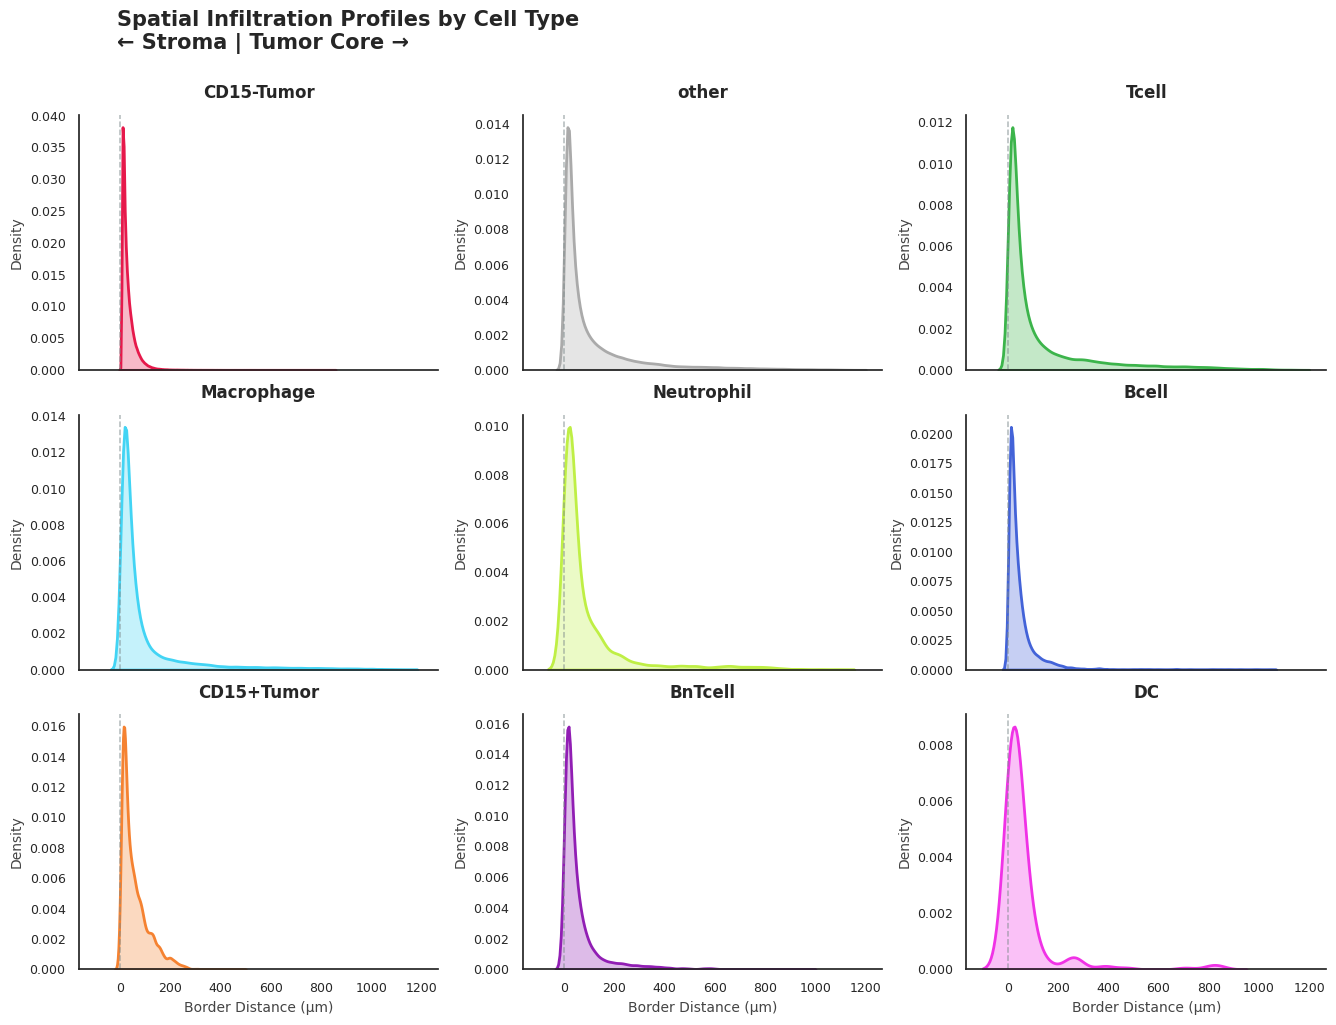

In [15]:
# interesują nas tylko tkanka nowotworowa in ROI (w środku guza)
sample_df_roi = sample_df[sample_df['in.ROI.tumor_tissue'] == True]

sns.set_theme(style="white", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

g = sns.displot(
    data=sample_df_roi,
    x='border.distance',
    hue='cell.type',
    col='cell.type',        # Create a separate column/panel for each cell type
    col_wrap=3,             # Wrap the grid at 3 columns per row
    kind='kde',             # Use Kernel Density Estimation
    palette=CT_PALETTE,
    fill=True,
    alpha=0.3,
    linewidth=2,
    common_norm=False,      # Normalize each cell type independently
    bw_adjust=0.8,
    height=3.5,             # Height of each individual panel
    aspect=1.3,             # Width-to-height aspect ratio of each panel
    facet_kws={'sharey': False}, # Let y-axes scale freely so sparse cells are visible
    legend=False            # Titles on panels replace the need for a global legend
)

for cell_type, ax in g.axes_dict.items():
    # Highlight the zero-boundary point
    ax.axvline(x=0, color='#7f8c8d', linestyle='--', linewidth=1.1, alpha=0.6)

    # Clear the standard "cell.type = X" title syntax for a cleaner look
    ax.set_title(cell_type, fontsize=12, weight='bold', pad=12)

    # Soften axis labels
    ax.set_xlabel('Border Distance (µm)', fontsize=10, color='#444444')
    ax.set_ylabel('Density', fontsize=10, color='#444444')

    # Adjust ticks slightly for aesthetics
    ax.tick_params(labelsize=9)

# Add an overarching layout adjustment
g.figure.subplots_adjust(top=0.88)
g.figure.suptitle('Spatial Infiltration Profiles by Cell Type\n← Stroma | Tumor Core →',
                   fontsize=15, weight='bold', x=0.1, ha='left')

plt.show()



T-celle są skoncentrowane blisko granicy ale zauważalnie już "w środku" nowotworu, znaczy że wnikają wgłąb nowotworu ale tylko niektóre schodzą na dużą głębokość.


### Spatial infiltration profile

In [81]:
def bin_cells_by_distance(df: pd.DataFrame, bin_size: int = 50):
    max = df['border.distance'].values.max()
    print(f"Maximum border distance: {max}")
    bins = np.arange(50, max + bin_size, bin_size)
    print(f"Bins: {bins}")
    bin_dict = {}

    # calculating the fraction for each bin
    for bin in bins:
        bin_mask = (df['border.distance'].values < bin) & (df['border.distance'].values >= bin - 50)

        filtered_df = df[bin_mask]
        if len(filtered_df) > 0:
            fraction = (filtered_df['cell.type'] == 'Tcell').sum() / len(filtered_df)
        else:
            fraction = 0.0

        bin_dict[bin] = fraction

    return bin_dict

In [82]:
bin_dict = bin_cells_by_distance(sample_df)

Maximum border distance: 1968.1556467921966
Bins: [  50.  100.  150.  200.  250.  300.  350.  400.  450.  500.  550.  600.
  650.  700.  750.  800.  850.  900.  950. 1000. 1050. 1100. 1150. 1200.
 1250. 1300. 1350. 1400. 1450. 1500. 1550. 1600. 1650. 1700. 1750. 1800.
 1850. 1900. 1950. 2000.]


In [83]:
bin_dict

{np.float64(50.0): np.float64(0.19591632320197078),
 np.float64(100.0): np.float64(0.25444962026386114),
 np.float64(150.0): np.float64(0.3040257609520778),
 np.float64(200.0): np.float64(0.3316217727075095),
 np.float64(250.0): np.float64(0.3454781275792949),
 np.float64(300.0): np.float64(0.36823400765445596),
 np.float64(350.0): np.float64(0.38426890105100014),
 np.float64(400.0): np.float64(0.37649865791828213),
 np.float64(450.0): np.float64(0.39267494098835),
 np.float64(500.0): np.float64(0.3749886969888778),
 np.float64(550.0): np.float64(0.3759087237479806),
 np.float64(600.0): np.float64(0.3826274228284279),
 np.float64(650.0): np.float64(0.3577573845712647),
 np.float64(700.0): np.float64(0.381025641025641),
 np.float64(750.0): np.float64(0.37667265827841023),
 np.float64(800.0): np.float64(0.39537626798773295),
 np.float64(850.0): np.float64(0.3945182724252492),
 np.float64(900.0): np.float64(0.37100139082058414),
 np.float64(950.0): np.float64(0.3689497716894977),
 np.floa

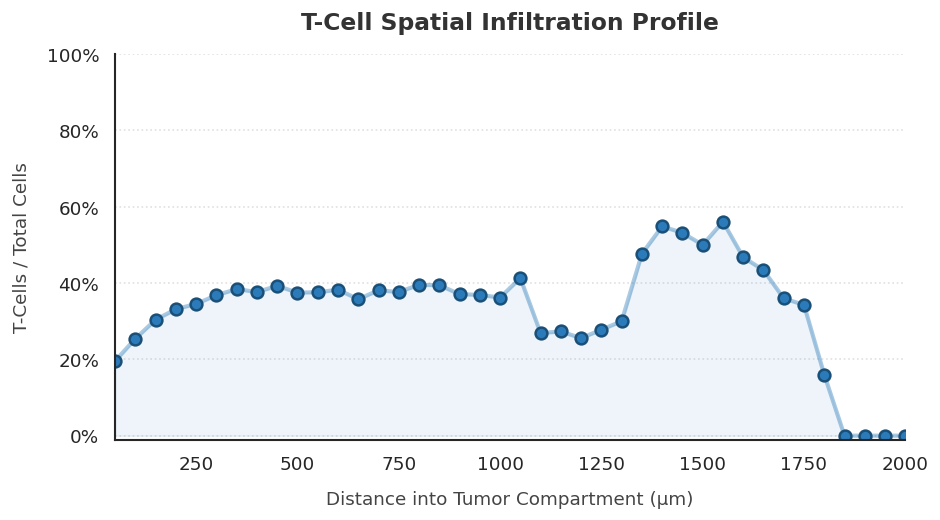

In [84]:
distances = np.array(list(bin_dict.keys()))
fractions = np.array(list(bin_dict.values()))

# Set clean scientific plotting style
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

# Initialize figure
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=120)

# 1. Plot a soft, smooth trendline underneath
ax.plot(distances, fractions, color='#2b7bba', linewidth=2.5, alpha=0.4, zorder=1)

# 2. Add the sharp scatter points over the line
ax.scatter(
    distances, fractions,
    color='#2b7bba',
    edgecolor='#1a4f78',
    s=50,
    linewidth=1.5,
    label='Observed T-cell Fraction',
    zorder=2
)

# 3. Add a visual background fill to highlight where the drop-off happens
ax.fill_between(distances, fractions, color='#2b7bba', alpha=0.08)

# 4. Polish labels and text
ax.set_title('T-Cell Spatial Infiltration Profile', fontsize=14, pad=15, weight='bold', color='#333333')
ax.set_xlabel('Distance into Tumor Compartment (µm)', fontsize=11, labelpad=10, color='#444444')
ax.set_ylabel('T-Cells / Total Cells', fontsize=11, labelpad=10, color='#444444')

# Clean up axes limits & formatting
ax.set_xlim(distances[0], distances[-1])
ax.set_ylim(-0.01, 1)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}')) # Show as percentages

# Remove chart junk frame lines
sns.despine(left=False, bottom=False)

# Add a subtle grid for density tracking
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#cccccc')

plt.tight_layout()
plt.show()

### T-cell infiltration score

In [39]:
def infiltration_score(df, ROI_name , cell_type='Tcell'):
  df_roi = df[df[ROI_name] == True]
  df_tcell_roi = df_roi[df_roi['cell.type'] == 'Tcell']

  return np.median(df_tcell_roi[['border.distance']])

In [40]:
infiltration_score(sample_df, 'in.ROI.tumor_tissue')

np.float64(43.126094189019575)

In [ ]:
infiltration_score_dict = {}

for file in SAMPLE_FILES:
    
    df = pd.read_csv(file, sep='\t')

    compute_border_distance(df)

    ROI_name = df.columns[-3] # unfortunately, the column name is not consistent across samples, this makes me very sad 
    print(ROI_name) # i assume the second to last column is the ROI column, if its diffrent across samples i will cry

    score = infiltration_score(df, ROI_name)

    patient_id = str(file).split("-")[2]

    infiltration_score_dict[patient_id] = score



in.ROI.tumor_tissue
Sample: tsv/cells_properties/LUNG-NSCLC2-0587-FIXT-01-IF1-01_#_cells_properties_#_fb439474f2166fe87b6d3087643b2af3_with_celltype.tsv Infiltration Score: 43.126094189019575
in.ROI.tumor_tissue
Sample: tsv/cells_properties/LUNG-NSCLC2-0664-FIXT-01-IF1-01_#_cells_properties_#_e2995fa6cfa5cfdbd51cc83e8e465177_with_celltype.tsv Infiltration Score: 37.8132251996566
in.ROI.tumor_tissue
Sample: tsv/cells_properties/LUNG-NSCLC2-0591-FIXT-01-IF1-01_#_cells_properties_#_b17f2afaad57821d4888ff6ba7f4b179_with_celltype.tsv Infiltration Score: 27.668393520404475
in.ROI.tumor_tissue
Sample: tsv/cells_properties/LUNG-NSCLC2-0612-FIXT-01-IF1-01_#_cells_properties_#_c948f5405a3f2243d3ef6d678823d805_with_celltype.tsv Infiltration Score: 23.479778533881962
in.ROI.tumor_tissue
Sample: tsv/cells_properties/LUNG-NSCLC2-0565-FIXT-01-IF1-01_#_cells_properties_#_12cf4d92f8de6204055505affdf85e90_with_celltype.tsv Infiltration Score: 27.136414434864093
in.ROI.tumor_tissue
Sample: tsv/cells_prop

In [74]:
infiltration_score_dict

{'0587': np.float64(43.126094189019575),
 '0664': np.float64(37.8132251996566),
 '0591': np.float64(27.668393520404475),
 '0612': np.float64(23.479778533881962),
 '0565': np.float64(27.136414434864093),
 '0657': np.float64(29.689223634174397),
 '0616': np.float64(20.934660255181523),
 '0558': np.float64(37.05199049983481),
 '0593': np.float64(25.083859352181353),
 '0721': np.float64(17.617321022221752),
 '0695': np.float64(13.710215169720216),
 '0613': np.float64(30.79366818032633),
 '0659': np.float64(26.41855408609566),
 '0696': np.float64(24.29814807758314),
 '0699': np.float64(54.87303527234952)}

In [75]:

print('patients ranked from most infiltrated to least:')
sorted(infiltration_score_dict, key=infiltration_score_dict.get, reverse=True)


patients ranked from most infiltrated to least:


['0699',
 '0587',
 '0664',
 '0558',
 '0613',
 '0657',
 '0591',
 '0565',
 '0659',
 '0593',
 '0696',
 '0612',
 '0616',
 '0721',
 '0695']

### bonus

In [66]:
def exp_decay(d, A, l):
    return A * np.exp(-d / l)


Maximum border distance: 1968.1556467921966
Bins: [  50.  100.  150.  200.  250.  300.  350.  400.  450.  500.  550.  600.
  650.  700.  750.  800.  850.  900.  950. 1000. 1050. 1100. 1150. 1200.
 1250. 1300. 1350. 1400. 1450. 1500. 1550. 1600. 1650. 1700. 1750. 1800.
 1850. 1900. 1950. 2000.]
Maximum border distance: 1847.9302935987594
Bins: [  50.  100.  150.  200.  250.  300.  350.  400.  450.  500.  550.  600.
  650.  700.  750.  800.  850.  900.  950. 1000. 1050. 1100. 1150. 1200.
 1250. 1300. 1350. 1400. 1450. 1500. 1550. 1600. 1650. 1700. 1750. 1800.
 1850.]
Maximum border distance: 1303.1976250745715
Bins: [  50.  100.  150.  200.  250.  300.  350.  400.  450.  500.  550.  600.
  650.  700.  750.  800.  850.  900.  950. 1000. 1050. 1100. 1150. 1200.
 1250. 1300. 1350.]
Maximum border distance: 686.7855851719671
Bins: [ 50. 100. 150. 200. 250. 300. 350. 400. 450. 500. 550. 600. 650. 700.]
Maximum border distance: 504.3126510409953
Bins: [ 50. 100. 150. 200. 250. 300. 350. 400. 4

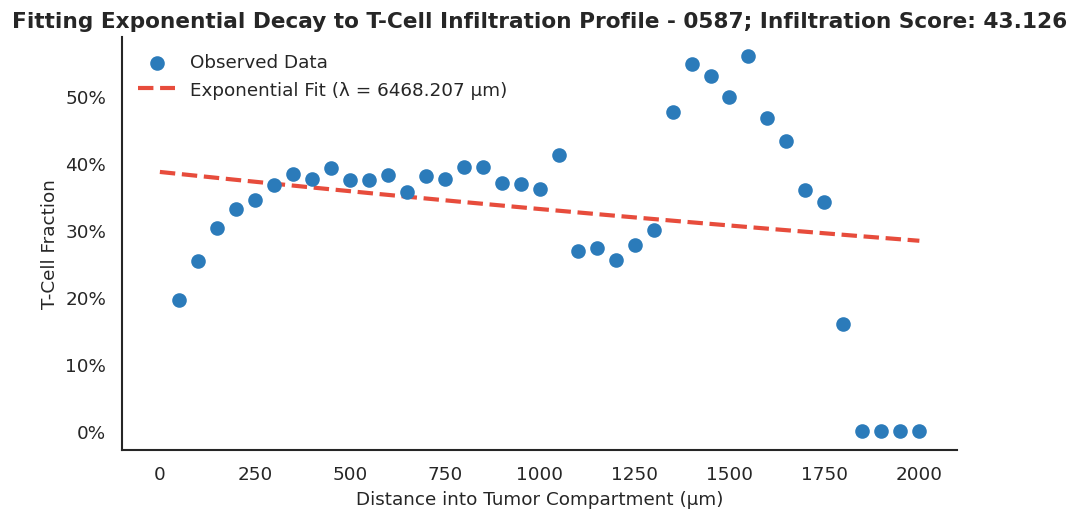

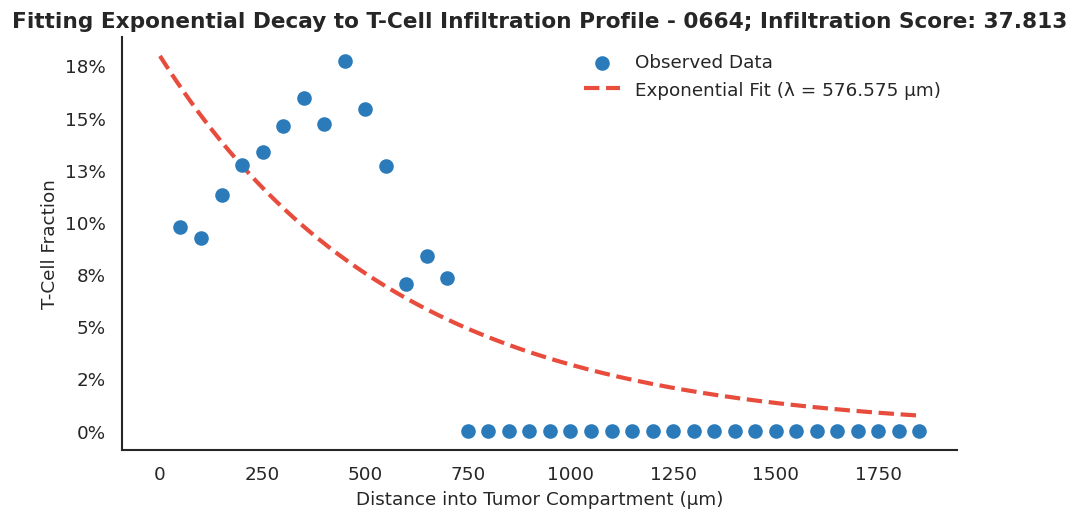

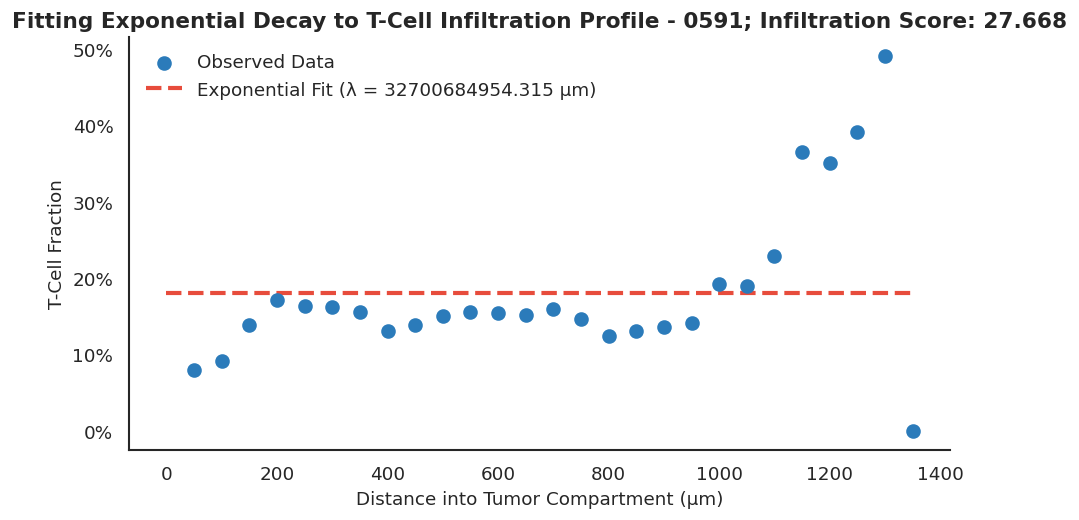

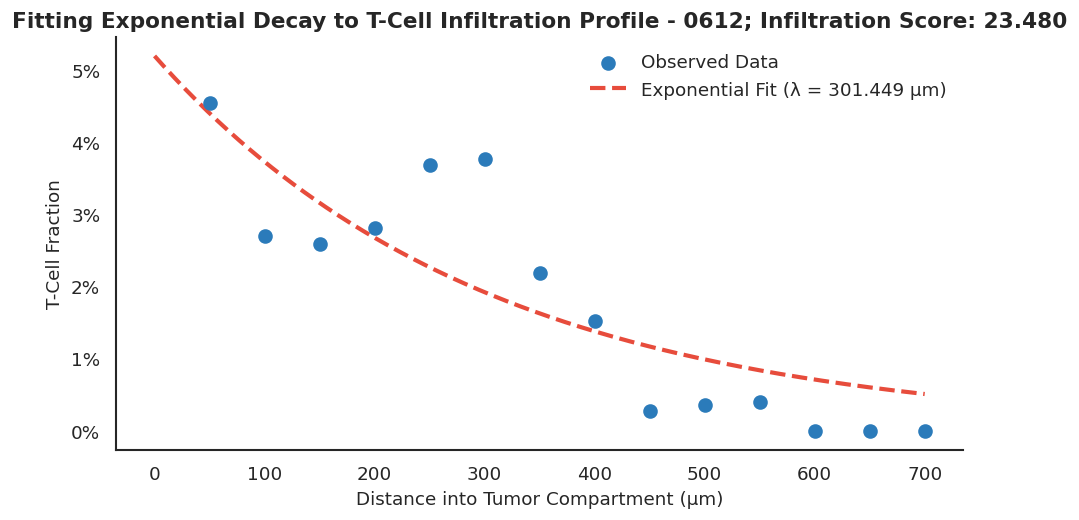

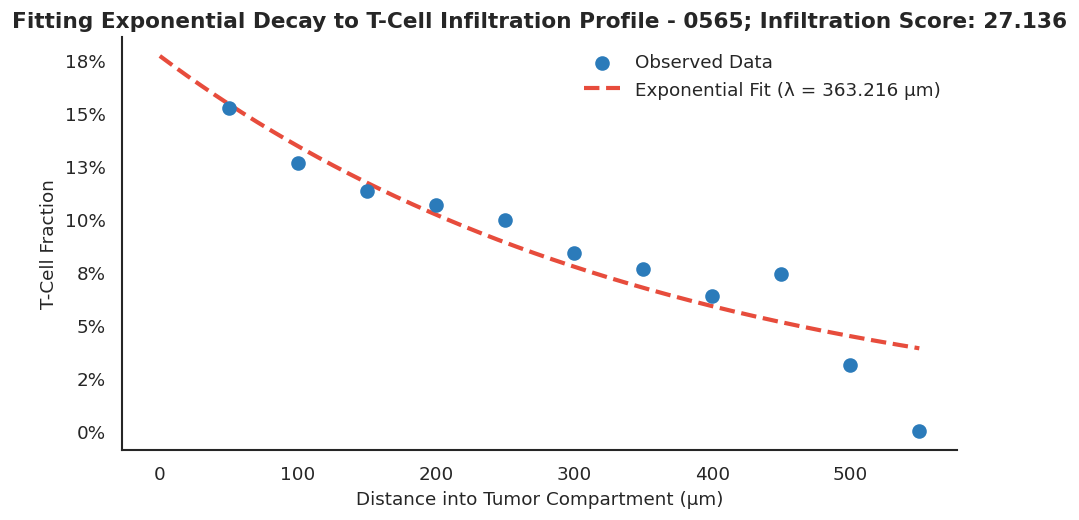

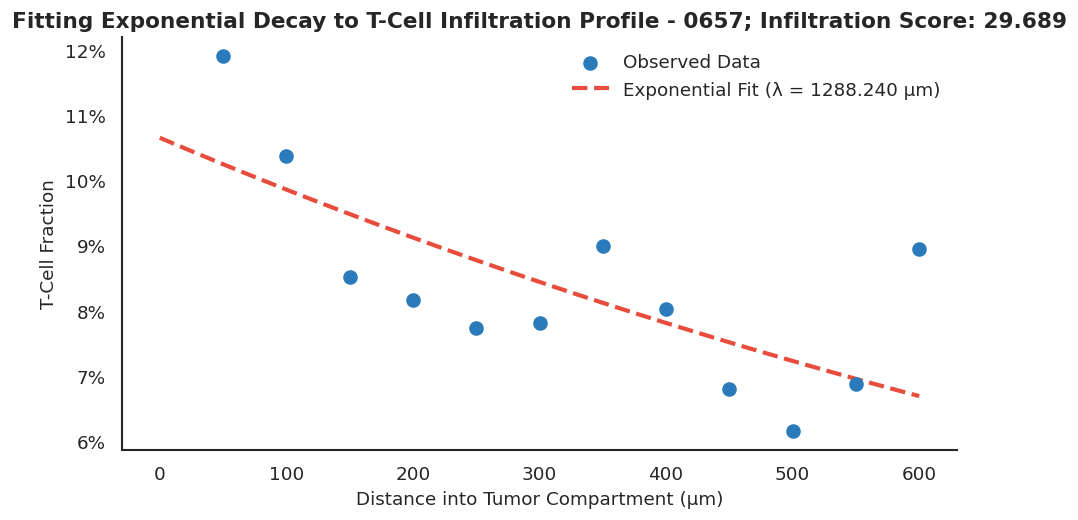

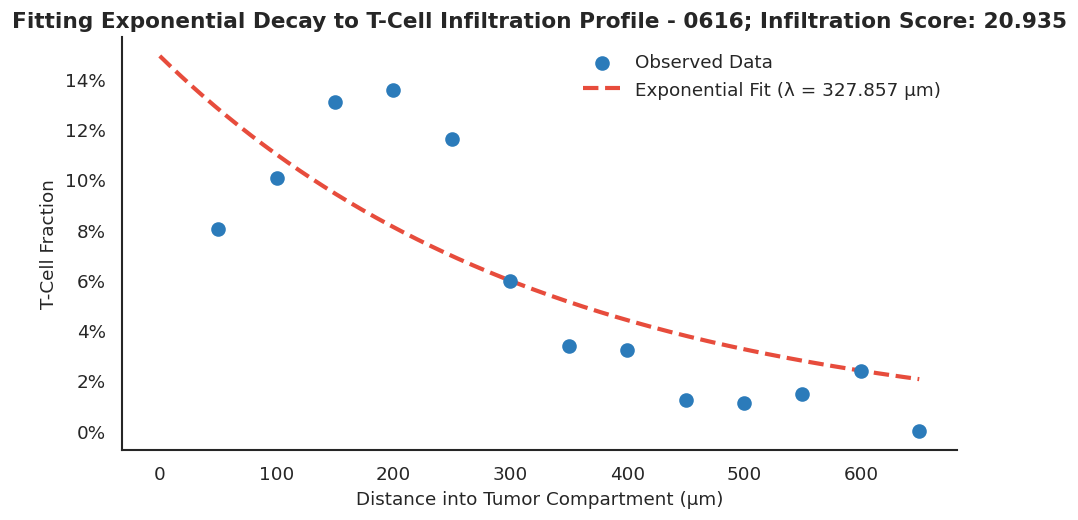

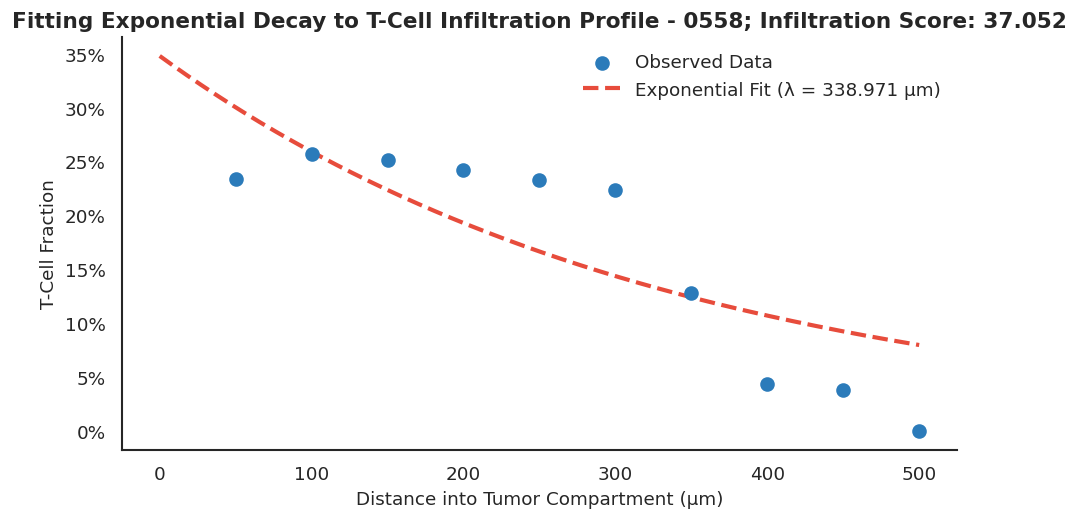

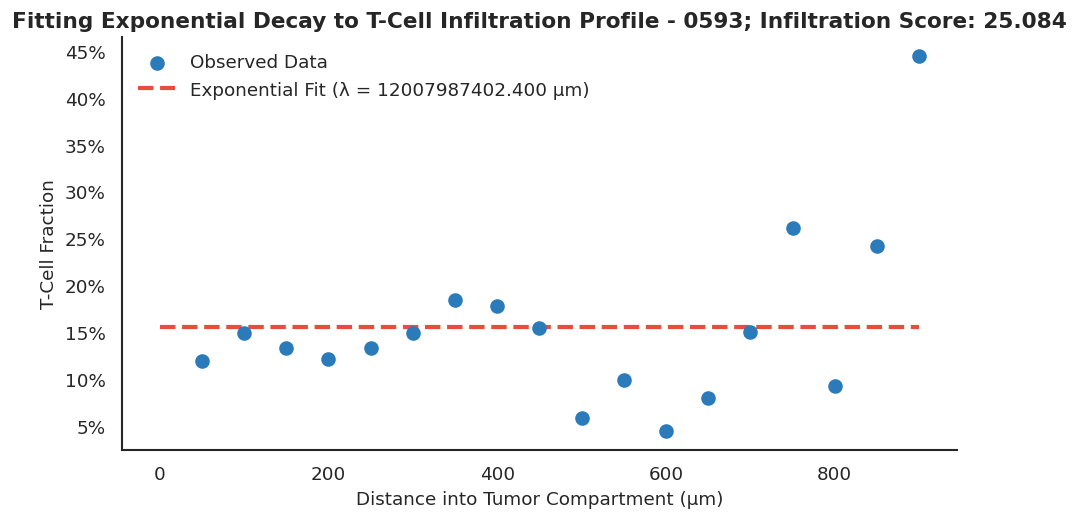

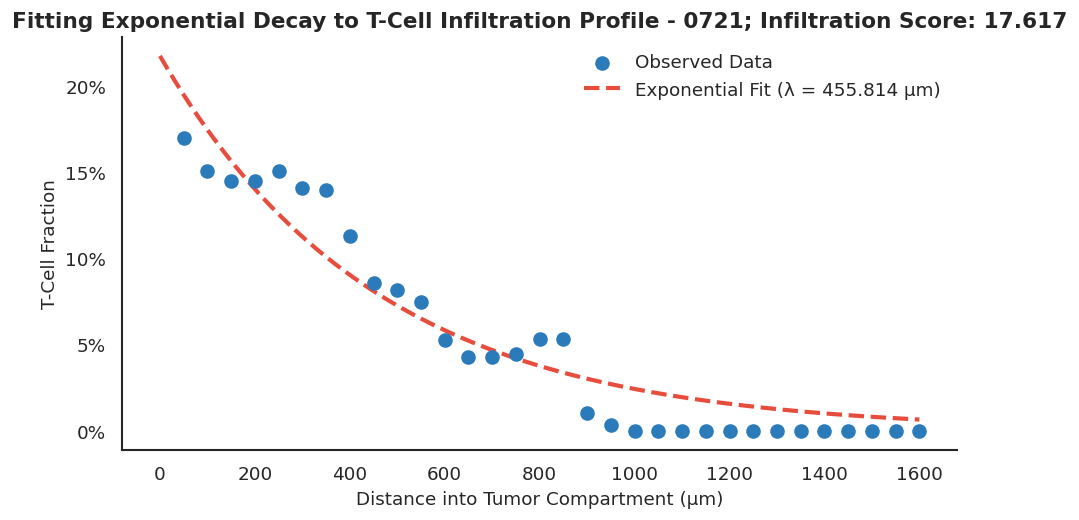

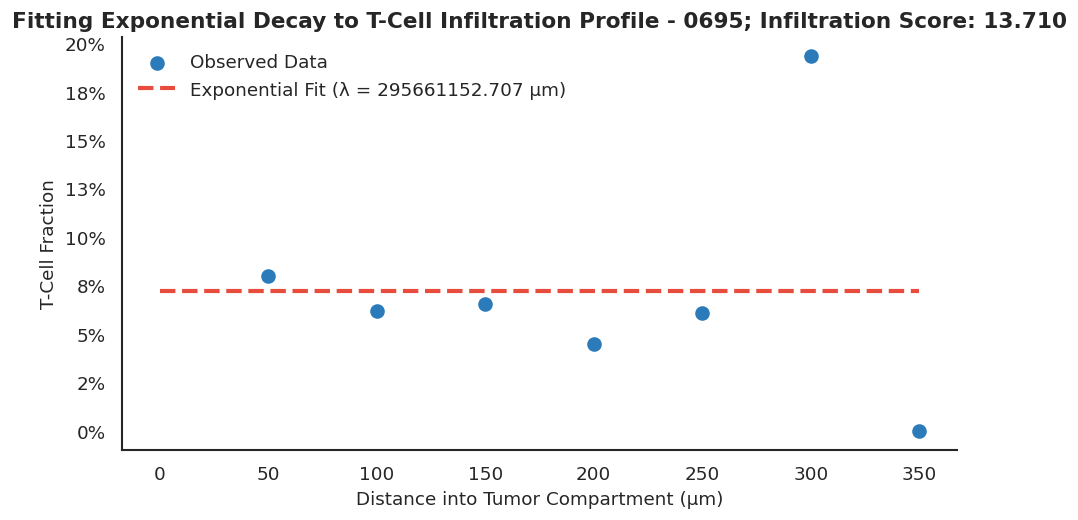

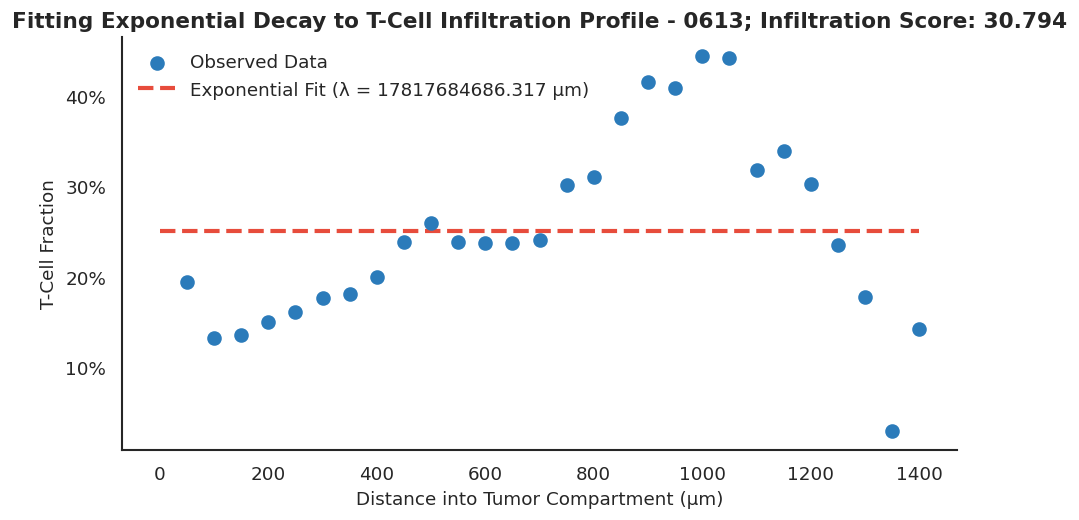

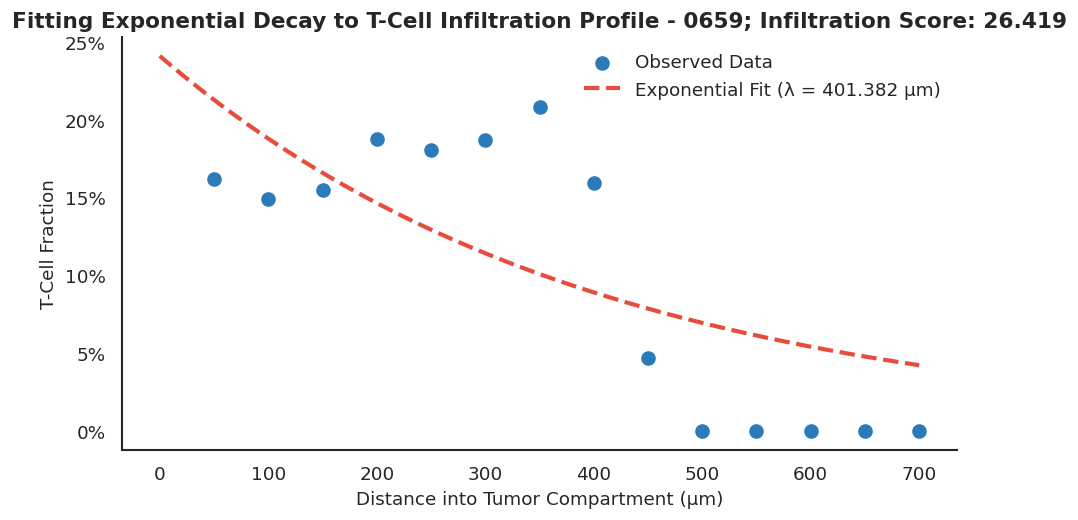

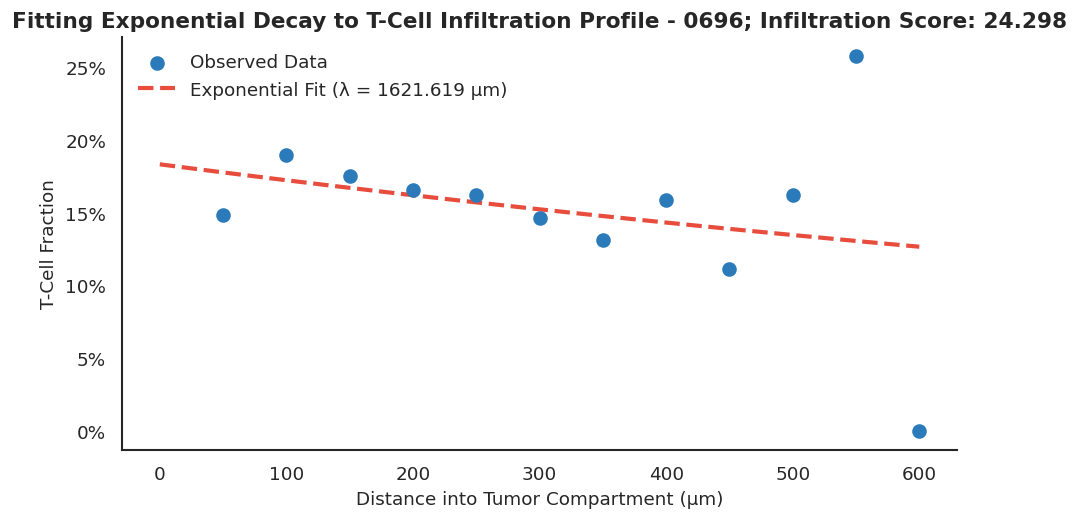

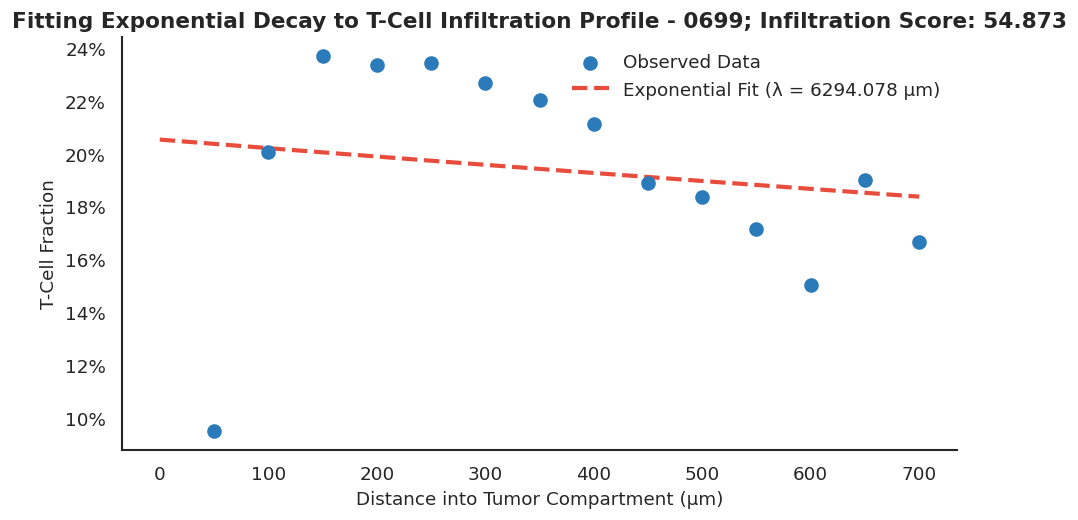

In [86]:
for file in SAMPLE_FILES:

    patient_id = str(file).split("-")[2]

    df = pd.read_csv(file, sep='\t')

    compute_border_distance(df)

    bin_dict = bin_cells_by_distance(df)
    
    distances = np.array(list(bin_dict.keys()))
    fractions = np.array(list(bin_dict.values()))

    # Fit the exponential decay model to the data

    # fit the model using curve_fit
    initial_guess = [0.5, 150]
    popt, pcov = curve_fit(exp_decay, distances, fractions, p0=initial_guess)

    # extract optimized parameters
    A_opt, lambda_opt = popt
    
    # Generate smooth curve data for plotting the fit
    smooth_distances = np.linspace(0, distances[-1], 500)
    fitted_fractions = exp_decay(smooth_distances, A_opt, lambda_opt)

    # Plot the original data points vs. the mathematical fit
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(8, 4.5), dpi=120)

    # Real data points
    ax.scatter(distances, fractions, color='#2b7bba', s=60, zorder=3, label='Observed Data')
    # The Fitted Exponential Decay Line
    ax.plot(smooth_distances, fitted_fractions, color='#e74c3c', linewidth=2.5,
            linestyle='--', label=f'Exponential Fit (λ = {lambda_opt:.3f} µm)')

    # Formatting details
    ax.set_title(f'Fitting Exponential Decay to T-Cell Infiltration Profile - {patient_id}; Infiltration Score: {infiltration_score_dict[patient_id]:.3f}', fontsize=13, weight='bold')
    ax.set_xlabel('Distance into Tumor Compartment (µm)', fontsize=11)
    ax.set_ylabel('T-Cell Fraction', fontsize=11)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend(frameon=False)
    sns.despine()
    plt.tight_layout()

plt.show()